# E-commerce Checkout Redesign — A/B Test Analysis

**Goal:** Determine whether a redesigned checkout flow (one-page checkout) changed conversion rate compared to the old multi-step checkout.

**Method:** Hypothesis testing (two-proportion z-test), confidence intervals, p-values, and effect size (Cohen's h).

**Groups:**
- **A (Control):** Old multi-step checkout
- **B (Treatment):** New one-page checkout

---


## 1. Setup & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep, proportion_confint

df = pd.read_csv("../data/ab_test_checkout_data.csv")
df.head()


,user_id,group,device_type,traffic_source,session_duration_sec,converted,cart_value_usd
0,A_001935,A,desktop,organic,67.7,0,0.0
1,B_000494,B,mobile,social,305.5,0,0.0
2,A_001720,A,mobile,social,137.9,0,0.0
3,B_003120,B,desktop,organic,113.4,0,0.0
4,A_000360,A,mobile,organic,173.0,0,0.0


In [2]:
df.info()
print("\nRows per group:")
print(df['group'].value_counts())


<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               12000 non-null  str    
 1   group                 12000 non-null  str    
 2   device_type           12000 non-null  str    
 3   traffic_source        12000 non-null  str    
 4   session_duration_sec  12000 non-null  float64
 5   converted             12000 non-null  int64  
 6   cart_value_usd        12000 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 656.4 KB

Rows per group:
group
A    6000
B    6000
Name: count, dtype: int64


## 2. Define Hypotheses

- **H0 (null):** The new checkout has no effect on conversion rate → $p_A = p_B$
- **H1 (alternative):** The new checkout changes conversion rate → $p_A \neq p_B$ (two-sided test)
- **Significance level:** $\alpha = 0.05$


## 3. Summary Statistics

In [3]:
summary = df.groupby("group")["converted"].agg(n="count", conversions="sum")
summary["conversion_rate"] = summary["conversions"] / summary["n"]
summary


,n,conversions,conversion_rate
group,,,
A,6000,713,0.118833
B,6000,854,0.142333


## 4. Hypothesis Test — Two-Proportion Z-Test

We use a z-test for two independent proportions since conversion is a binary outcome (converted / not converted) with large sample sizes in each group.


In [4]:
n_a, n_b = summary.loc["A", "n"], summary.loc["B", "n"]
x_a, x_b = summary.loc["A", "conversions"], summary.loc["B", "conversions"]
p_a, p_b = summary.loc["A", "conversion_rate"], summary.loc["B", "conversion_rate"]

count = np.array([x_b, x_a])
nobs = np.array([n_b, n_a])
z_stat, p_value = proportions_ztest(count, nobs, alternative="two-sided")

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value:     {p_value:.6f}")
print(f"Significant at alpha=0.05? {'YES' if p_value < 0.05 else 'NO'}")


Z-statistic: 3.8201
P-value:     0.000133
Significant at alpha=0.05? YES


**Interpretation:** The p-value tells us the probability of observing a difference this large (or larger) if there were truly no effect (H0 true). A p-value below 0.05 means we reject H0 — the conversion rate difference is statistically significant.

## 5. Confidence Interval for the Difference (B − A)

In [5]:
ci_low, ci_high = confint_proportions_2indep(
    count1=x_b, nobs1=n_b, count2=x_a, nobs2=n_a, method="wald"
)
diff = p_b - p_a
rel_lift = diff / p_a * 100

print(f"Absolute difference: {diff*100:.2f} percentage points")
print(f"Relative lift:       {rel_lift:.2f}%")
print(f"95% CI:              [{ci_low*100:.2f}pp, {ci_high*100:.2f}pp]")
print(f"CI excludes 0?       {'YES -> supports real effect' if ci_low > 0 or ci_high < 0 else 'NO'}")


Absolute difference: 2.35 percentage points
Relative lift:       19.78%
95% CI:              [1.15pp, 3.55pp]
CI excludes 0?       YES -> supports real effect


**Interpretation:** We're 95% confident the *true* difference in conversion rate lies within this interval. Since the interval does not include 0, this supports a genuine (not just chance) improvement.

## 6. Effect Size — Cohen's h

Statistical significance tells us *whether* an effect exists — effect size tells us *how big* it is. With large samples, even tiny, practically unimportant differences can become "significant," so effect size is essential for a business call.

In [6]:
def cohens_h(p1, p2):
    phi1 = 2 * np.arcsin(np.sqrt(p1))
    phi2 = 2 * np.arcsin(np.sqrt(p2))
    return phi1 - phi2

h = cohens_h(p_b, p_a)
abs_h = abs(h)
magnitude = ("negligible" if abs_h < 0.2 else "small" if abs_h < 0.5
             else "medium" if abs_h < 0.8 else "large")

print(f"Cohen's h: {h:.4f}  ({magnitude} effect)")


Cohen's h: 0.0698  (negligible effect)


**Interpretation:** Cohen's h here is small/negligible by conventional thresholds, even though the test is statistically significant. This is a classic case of *"statistically significant but practically small"* — important to flag to stakeholders rather than overselling the result.

## 7. Visualization

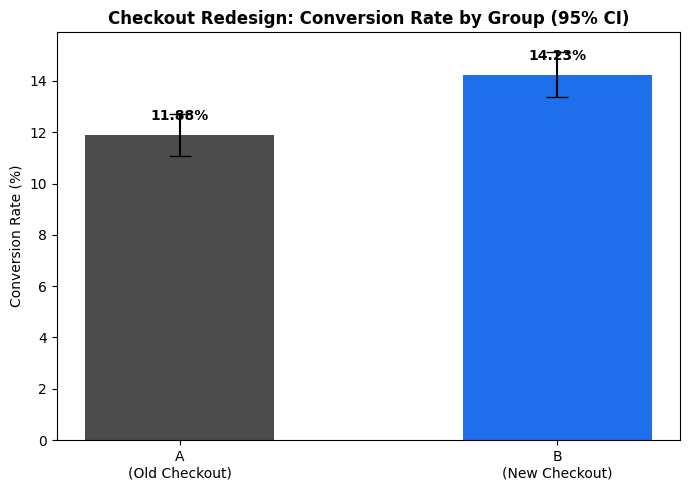

In [7]:
cis = {}
for g in ["A", "B"]:
    low, high = proportion_confint(summary.loc[g, "conversions"], summary.loc[g, "n"],
                                    alpha=0.05, method="wilson")
    cis[g] = (low, high)

fig, ax = plt.subplots(figsize=(7, 5))
groups = ["A\n(Old Checkout)", "B\n(New Checkout)"]
rates = [summary.loc["A", "conversion_rate"] * 100, summary.loc["B", "conversion_rate"] * 100]
errors = [
    [(summary.loc[g, "conversion_rate"] - cis[g][0]) * 100 for g in ["A", "B"]],
    [(cis[g][1] - summary.loc[g, "conversion_rate"]) * 100 for g in ["A", "B"]],
]
bars = ax.bar(groups, rates, color=["#4C4C4C", "#1F6FEB"], width=0.5, yerr=errors, capsize=8)
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, rate + 0.6, f"{rate:.2f}%", ha="center", fontweight="bold")
ax.set_ylabel("Conversion Rate (%)")
ax.set_title("Checkout Redesign: Conversion Rate by Group (95% CI)", fontweight="bold")
plt.tight_layout()
plt.show()


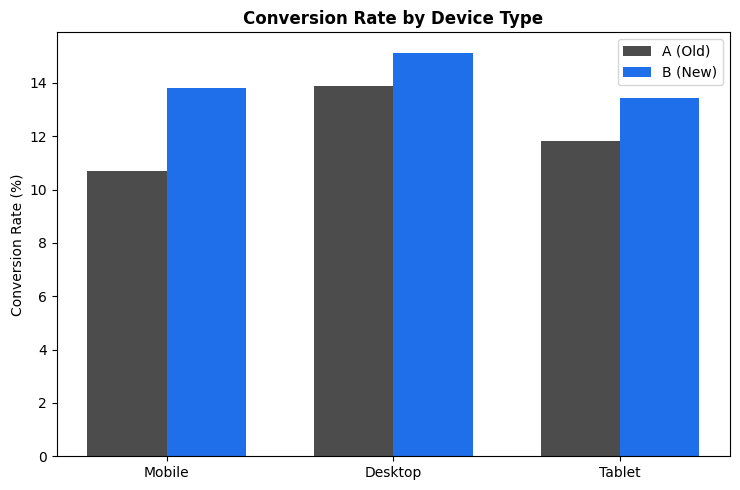

In [8]:
device_summary = df.groupby(["device_type", "group"])["converted"].mean().reset_index()
device_pivot = device_summary.pivot(index="device_type", columns="group", values="converted") * 100
device_pivot = device_pivot.reindex(["mobile", "desktop", "tablet"])

x = np.arange(len(device_pivot.index))
width = 0.35
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.bar(x - width/2, device_pivot["A"], width, label="A (Old)", color="#4C4C4C")
ax.bar(x + width/2, device_pivot["B"], width, label="B (New)", color="#1F6FEB")
ax.set_xticks(x)
ax.set_xticklabels([d.capitalize() for d in device_pivot.index])
ax.set_ylabel("Conversion Rate (%)")
ax.set_title("Conversion Rate by Device Type", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Business Recommendation

**Verdict:** The new one-page checkout (B) shows a statistically significant improvement in conversion rate over the old checkout (A):
- Absolute lift: **+2.35 percentage points** (11.88% → 14.23%)
- Relative lift: **~19.8%**
- 95% CI of the difference: **[1.15pp, 3.55pp]** — excludes zero
- p-value: **0.0001** (well below 0.05)
- Effect size (Cohen's h): **negligible-to-small** in conventional terms

**Recommendation:** Roll out the new checkout design. The result is statistically robust (not due to chance), and while the standardized effect size is modest, a ~20% relative lift in conversion is commercially meaningful at scale — especially since the redesign carries low implementation risk. Mobile users, who make up the majority of traffic, should be monitored closely post-launch since device-level effects vary.

**Caveat:** This analysis uses simulated data for demonstration. In a real deployment, also check for novelty effects (re-test after a few weeks), sample ratio mismatch, and guardrail metrics like revenue per visitor and cart abandonment reasons.
